# DATA PREPROCESSING

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../1-Data/heart.csv")
print('Shape',df.shape)

Shape (918, 12)


# TASK
- Remove the RestingBP outliers
- Encoding Categorical Features
- Split Train/Test
- Handle missing values (choresterol)
- Feature Scaling

# 1. Remove the RestingBp outliers
Since only 1 value RestingBp is equal 0 --> We can delete it without interupting anything else

In [4]:
df_model = df.copy()
df_model = df_model[df_model["RestingBP"] > 0]

print("Shape after removing RestingBP outliers:")
print(df_model.shape)

Shape after removing RestingBP outliers:
(917, 12)


# 2. Encoding Categorical Features
## Binary Features 
Only 2 categories --> Label Encoding (0/1):
- Sex: M -> 1, F -> 0
- Fasting B/S: already 0/1
- ExerciseAngina: Y -> 1, N -> 0

## Multi-category features 
I use one-hot encoding
- ChestPainType: 4 values → 3 dummy columns (drop_first=True)
- RestingECG: 3 values → 2 dummy columns
- ST_Slope: 3 values → 2 dummy columns

**Why drop one column:**  Dropping one dummy column avoids the Dummy Variable Trap (perfect multicollinearity). When all dummy variables for a categorical feature are included along with an intercept term, one column becomes perfectly predictable from the others because the dummy variables always sum to 1. This makes the feature matrix non–full rank, causing unstable or non-unique coefficient estimates in Logistic Regression. By dropping one category, we create a reference category that the model infers implicitly, eliminating the redundancy.

In [5]:
df_model['Sex'] = df_model['Sex'].map({'M': 1, 'F': 0})
df_model['ExerciseAngina'] = df_model['ExerciseAngina'].map({'Y': 1, 'N': 0})

df_model = pd.get_dummies(df_model, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True, dtype=int)

In [6]:
print(df_model.shape)
df_model.head()

(917, 16)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1


# 3. Split Train/Test  
I decided to split to 80 train - 20 test

In [20]:
from sklearn.model_selection import train_test_split

X = df_model.drop('HeartDisease', axis=1)
y = df_model['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # preserve class distribution -> ensure both train and test set have same ratio
)
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print(f"Train: {df_train.shape}, Test: {df_test.shape}")
df_train.to_csv("../1-Data/train_data.csv", index=False)
df_test.to_csv("../1-Data/test_data.csv", index=False)

Train: (733, 16), Test: (184, 16)


In [19]:
df = pd.read_csv("../1-Data/train_data.csv")
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,49,1,128,212,0,96,1,0.0,0,0,0,1,0,1,0,1
1,68,1,134,254,1,151,1,0.0,0,1,0,1,0,0,1,0
2,59,1,126,218,1,134,0,2.2,0,1,0,1,0,1,0,1
3,67,1,125,254,1,163,0,0.2,0,0,0,1,0,1,0,1
4,52,1,160,331,0,94,1,2.5,0,0,0,1,0,1,0,1


# 4. Handle missing value on train_data
Using median to replace zero of non-zero Cholesterol values  
Why median (not mean)? Cholesterol distributions are right-skewed; median is more robust to outliers.

In [ ]:
# Replace 0 Cholesterol with median of non-zero values
median_chol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_chol)

# Check RestingBP zeros
print(f"RestingBP zeros: {(df['RestingBP'] == 0).sum()}")

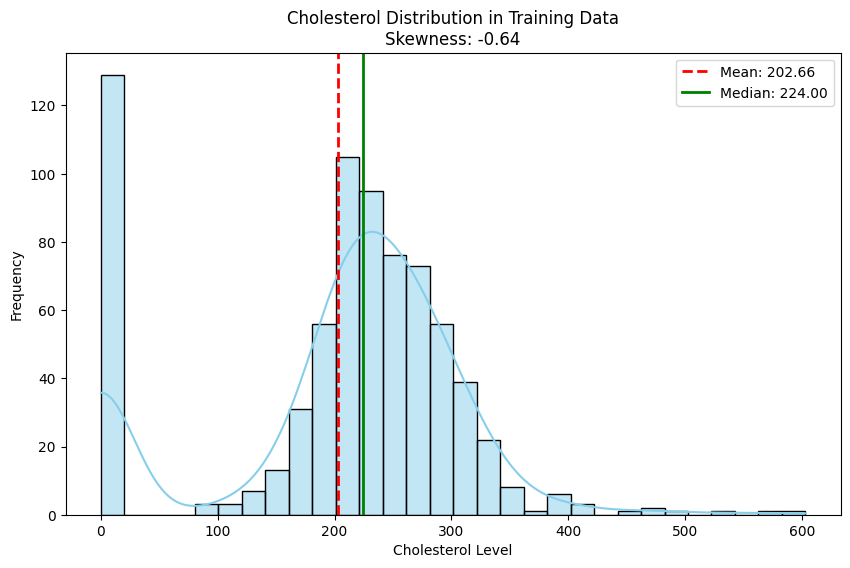

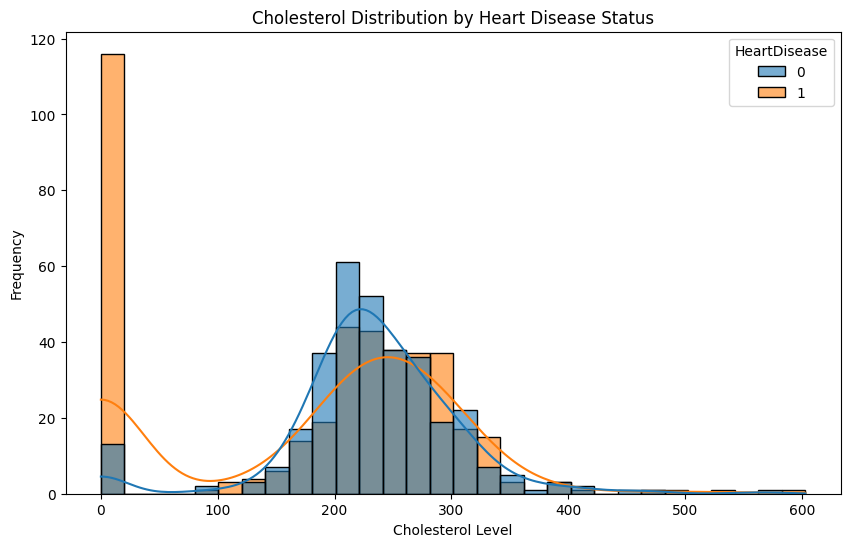

Skewness: -0.64 (>0 indicates right-skewed)
Mean: 202.66
Median: 224.00


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    # ← ONLY transform, never fit on test